<a href="https://colab.research.google.com/github/Aniket-Kumar-7/Machine-Learning/blob/main/Decision_Tree_Algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=sbn.load_dataset('titanic')

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.shape

(891, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
df.isnull().sum()/len(df)*100

,0
survived,0.000000
pclass,0.000000
sex,0.000000
age,19.865320
sibsp,0.000000
parch,0.000000
fare,0.000000
embarked,0.224467
class,0.000000
who,0.000000


In [ ]:
df.drop('deck',axis=1,inplace=True)

In [ ]:
df.drop(['who','embark_town','embarked','class'],axis=1,inplace=True)

In [ ]:
df.drop('alive',axis=1,inplace=True)

<Axes: xlabel='age', ylabel='Count'>

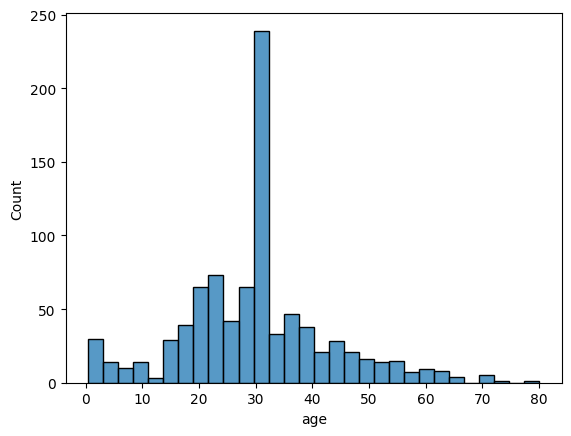

In [ ]:
df['age']=df['age'].fillna(df['age'].mean())
sbn.histplot(df['age'])

In [ ]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
lbl=LabelEncoder()
stdslr=StandardScaler()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   sex         891 non-null    object 
 3   age         891 non-null    float64
 4   sibsp       891 non-null    int64  
 5   parch       891 non-null    int64  
 6   fare        891 non-null    float64
 7   adult_male  891 non-null    bool   
 8   alone       891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(1)
memory usage: 50.6+ KB


In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,True,False
1,1,1,female,38.0,1,0,71.2833,False,False
2,1,3,female,26.0,0,0,7.9250,False,True
3,1,1,female,35.0,1,0,53.1000,False,False
4,0,3,male,35.0,0,0,8.0500,True,True


In [ ]:
cols=['sex','adult_male','alone']
for col in cols:
  df[col]=lbl.fit_transform(df[col])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   sex         891 non-null    int64  
 3   age         891 non-null    float64
 4   sibsp       891 non-null    int64  
 5   parch       891 non-null    int64  
 6   fare        891 non-null    float64
 7   adult_male  891 non-null    int64  
 8   alone       891 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 62.8 KB


In [ ]:
df.duplicated().sum()
df[df.duplicated()].head()
df[df.duplicated(keep=False)].head()

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone
4,0,3,1,35.000000,0,0,8.0500,1,1
26,0,3,1,29.699118,0,0,7.2250,1,1
28,1,3,0,29.699118,0,0,7.8792,0,1
29,0,3,1,29.699118,0,0,7.8958,1,1
32,1,3,0,29.699118,0,0,7.7500,0,1


In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone
0,0,3,1,22.0,1,0,7.2500,1,0
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,0,1
3,1,1,0,35.0,1,0,53.1000,0,0
4,0,3,1,35.0,0,0,8.0500,1,1


In [ ]:
from sklearn.model_selection import train_test_split
X=df.drop('survived',axis=1)
y=df['survived']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,random_state=42)

In [ ]:
X_train.head(),y_train.head()

(     pclass  sex   age  sibsp  parch     fare  adult_male  alone
 331       1    1  45.5      0      0  28.5000           1      1
 733       2    1  23.0      0      0  13.0000           1      1
 382       3    1  32.0      0      0   7.9250           1      1
 704       3    1  26.0      1      0   7.8542           1      0
 813       3    0   6.0      4      2  31.2750           0      0,
 331    0
 733    0
 382    0
 704    0
 813    0
 Name: survived, dtype: int64)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(random_state=42)

In [ ]:
model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
y_pred

array([0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0])

In [ ]:
from sklearn.metrics import accuracy_score,r2_score,classification_report,confusion_matrix

In [ ]:
accuracy_score(y_pred,y_test)

0.7430167597765364

In [ ]:
confusion_matrix(y_pred,y_test)

array([[79, 20],
       [26, 54]])

In [ ]:
df[['age','fare']]=stdslr.fit_transform(df[['age','fare']])

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone
0,0,3,1,-0.592481,1,0,-0.502445,1,0
1,1,1,0,0.638789,1,0,0.786845,0,0
2,1,3,0,-0.284663,0,0,-0.488854,0,1
3,1,1,0,0.407926,1,0,0.420730,0,0
4,0,3,1,0.407926,0,0,-0.486337,1,1


In [ ]:
X_scaled=df.drop('survived',axis=1)
y_scaled=df['survived']

In [ ]:
X_train_scaled,X_test_scaled,y_train_scaled,y_test_scaled=train_test_split(X_scaled,y_scaled,test_size=.20,random_state=42)

In [ ]:
model.fit(X_train_scaled,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_scaled=model.predict(X_test_scaled)

In [ ]:
y_pred_scaled

array([0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0])

In [ ]:
accuracy_score(y_pred_scaled,y_test_scaled)

0.7430167597765364

In [ ]:
model.fit(X_train_scaled,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_=model.predict(X_test_scaled)

In [ ]:
accuracy_score(y_,y_test)

0.7430167597765364

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model=SVC(kernel='rbf')

In [ ]:
svm_model.fit(X_train_scaled,y_train)

SVC()

In [ ]:
y_pred_svm=svm_model.predict(X_test_scaled)

In [ ]:
accuracy_score(y_pred_svm,y_test)*100

81.56424581005587

In [ ]:
print(classification_report(y_pred_svm,y_test))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85       112
           1       0.73      0.81      0.77        67

    accuracy                           0.82       179
   macro avg       0.80      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

